# Q-Learning for Efficient Path Optimization in GridWorld Navigation

## Import Important Libraries

In [262]:
import numpy as np
import matplotlib.pyplot as plt
from random import sample
from time import sleep
from IPython.display import clear_output
import seaborn as sns
from random import sample, choice
import pandas as pd
import random
from collections import deque
from collections import defaultdict
import time
from sklearn.model_selection import ParameterGrid
from itertools import product
import pickle
from scipy import stats

## GridWord Environment

This GridWorld class defines the environment for a grid-based simulation project. It supports agent movement, reward mechanisms, and rendering:
* __init__: Sets up the grid, obstacles, start/goal states, and action space.
* reset: Initializes the agent's position.
* step: Processes actions, validates moves, assigns rewards, and checks if the goal is reached.
* render: Visualizes the grid with obstacles, start, goal, and agent positions.

        

In [265]:
class GridWorld:
    def __init__(self, width, height, obstacle_locations, start=None, goal=None):
        self.width = width
        self.height = height
        self.obstacles = set(obstacle_locations)
        self.initial_start = start
        self.start = start
        self.goal = goal
        self.state = None
        self.action_space = Discrete(4)  # Now using the Discrete class

        self.reset()
        
        # Define observation space (number of grid cells)
        self.observation_space = (self.width * self.height)  # Grid size as a tuple (width, height)

    def reset(self):
        """Set fixed start and goal positions if provided."""
        self.state = self.start
        return self.state  # Return state as tuple (x, y)

    def is_valid_state(self, state):
        """Check if the state is within bounds and not an obstacle."""
        x, y = state
        return (0 <= x < self.width) and (0 <= y < self.height) and (state not in self.obstacles)

    def step(self, action):
        x, y = self.state
        if action == 0:  # Up
            y += 1
        elif action == 1:  # Down
            y -= 1
        elif action == 2:  # Left
            x -= 1
        elif action == 3:  # Right
            x += 1

        new_state = (x, y)
        if self.is_valid_state(new_state):
            self.state = new_state

        # Predefined rewards
        goal_reward = 100
        wall_penalty = -10
        step_penalty = -1

        if self.state == self.goal:
            reward = goal_reward
            done = True
        elif self.state in self.obstacles:
            reward = wall_penalty
            done = True
        else:
            reward = step_penalty
            done = False

        return self.state, reward, done

    def render(self):
        """Render the grid world."""
        fig, ax = plt.subplots(figsize=(6, 6))
        for x in range(self.width):
            for y in range(self.height):
                if (x, y) in self.obstacles:
                    ax.add_patch(plt.Rectangle((x, y), 1, 1, color="red"))
                elif (x, y) == self.goal:
                    ax.add_patch(plt.Rectangle((x, y), 1, 1, color="green"))
                elif (x, y) == self.initial_start:
                    ax.add_patch(plt.Rectangle((x, y), 1, 1, color="yellow"))
                else:
                    ax.add_patch(plt.Rectangle((x, y), 1, 1, color="black"))
        ax.plot(self.state[0] + 0.5, self.state[1] + 0.5, "bo", markersize=20)
        ax.set_xticks(np.arange(0, self.width + 1, 1))
        ax.set_yticks(np.arange(0, self.height + 1, 1))
        ax.set_xlim(0, self.width)
        ax.set_ylim(0, self.height)
        ax.set_aspect("equal")
        plt.gca().invert_yaxis()
        plt.show()

class Discrete:
    def __init__(self, n):
        self.n = n

    def sample(self):
        return np.random.randint(self.n)

    def __str__(self):
        return f"Discrete({self.n})" 


## Initialize and Validate Environment

State space: 100
Action space: Discrete(4)
State: 0


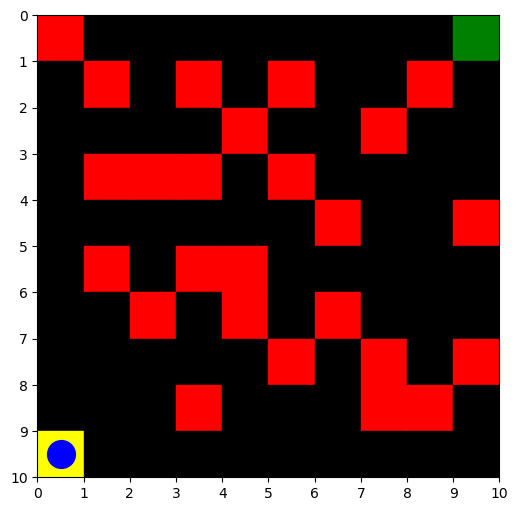

In [267]:
# Predefined obstacle positions
obstacles = [
    (0, 0), (1, 1), (1, 3), (3, 1), (3, 3), (4, 2), (3, 5), (6, 4), (4, 5), (5, 1), (1, 5), 
    (2, 6), (5, 3), (7, 2), (8, 1), (5, 7), (2, 3), (6, 6), (8, 8), (7, 7), (9, 4), 
    (3, 8), (7, 8), (9, 7), (4, 6)
]

# initilize the grid world with predefined obstacles
env = GridWorld(width=10, height=10, obstacle_locations=obstacles, start = (0,9), goal = (9,0))
state, _ = env.reset()

# Print dimensions of state and action space
print("State space: {}".format(env.observation_space))
print("Action space: {}".format(env.action_space))


# Print output
print("State: {}".format(state))
#print("Action: {}".format(action))

# Render the environment frame and display it
env.render()

## Stimulate the Environment

This code runs a simulation where an agent randomly selects actions in the `GridWorld` environment.
The environment is reset, and the agent takes steps until it either reaches the goal, hits an obstacle, or exceeds the maximum steps.
At each step, the environment's state is rendered for visualization, and the simulation continues for a set number of steps.


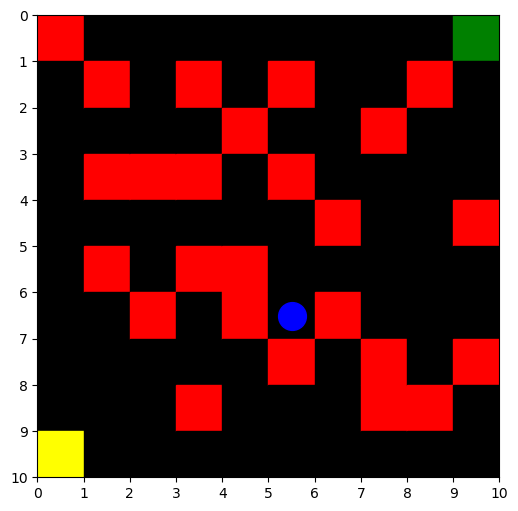

Simulation ended after 50 steps. Final state: (5, 6), Reward: -1


In [270]:
# Reset the environment
state = env.reset()
done = False
steps = 0
max_steps = 50

while not done and steps < max_steps:
    # Randomly choose an action
    action = np.random.randint(4)  # Random action

    
    # Perform the action in the environment and get the new state, reward, and done status
    state, reward, done = env.step(action)

    # Render the environment
    clear_output(wait=True)  # Clears previous output (only works in Jupyter)
    env.render()  # Displays the environment's current state

    # Add a delay for better visualization
    sleep(0.5)

    # Increment the step counter
    steps += 1

# After the simulation ends, print the results
print(f"Simulation ended after {steps} steps. Final state: {state}, Reward: {reward}")


## Implementing the Agent

This `QLearningAgent` class implements a Q-learning agent for reinforcement learning:
- `__init__`: Initializes the Q-table, hyperparameters (learning rate, discount factor, etc.), and tracking lists for rewards and steps.
- `get_exploration_rate`: Calculates the exploration rate that decays over episodes, balancing exploration vs. exploitation.
- `get_action`: Chooses an action based on the exploration rate (random action vs. action with highest Q-value).
- `update_q_table`: Updates the Q-value for a given state-action pair using the Q-learning update rule.
- `reset_episode_tracking`: Resets tracking of rewards and steps for a new episode.


In [273]:
class QLearningAgent:
    def __init__(self, env, learning_rate=0.1, discount_factor=0.1, exploration_start=0.1, exploration_end=0.01, num_episodes=100):
        self.q_table = np.zeros((env.height, env.width, 4))  # Q-table initialization assuming 4 actions
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_start = exploration_start
        self.exploration_end = exploration_end
        self.num_episodes = num_episodes
        self.exploration_rate = exploration_start  # Track the current exploration rate

        # Initialize episode tracking lists
        self.episode_rewards = []  # Tracks cumulative rewards per episode
        self.episode_steps = []    # Tracks steps per episode

    def get_exploration_rate(self, current_episode):
        # Decay exploration rate over episodes
        self.exploration_rate = self.exploration_start * (self.exploration_end / self.exploration_start) ** (current_episode / self.num_episodes)
        return self.exploration_rate

    def get_action(self, state, current_episode):
        exploration_rate = self.get_exploration_rate(current_episode)
        if np.random.rand() < exploration_rate:
            return np.random.randint(4)  # Random action
        else:
            return np.argmax(self.q_table[state])  # Action with the highest Q-value

    def update_q_table(self, state, action, next_state, reward):
        best_next_action = np.argmax(self.q_table[next_state])
        current_q_value = self.q_table[state][action]
        new_q_value = current_q_value + self.learning_rate * (reward + self.discount_factor * self.q_table[next_state][best_next_action] - current_q_value)
        self.q_table[state][action] = new_q_value

    def reset_episode_tracking(self):
        """Reset the lists that track episode rewards and steps"""
        self.episode_rewards.clear()
        self.episode_steps.clear()


## Training The Agent

 This `train_agent` function trains the Q-learning agent over a specified number of episodes:
 - It initializes the environment and agent for each episode.
 - The agent selects actions using its `get_action` method, updates its Q-table, and accumulates rewards and steps.
 - After each episode, the total reward, steps, and the agent's path (sequence of states) are tracked.
 - The function returns the cumulative rewards, steps per episode, and the paths followed by the agent.


In [276]:
def train_agent(agent, env, num_episodes=1000):
    # Lists to store the data for plotting
    episode_rewards = []
    episode_steps = []
    all_paths = []
    episode_times = []

    # Loop over the specified number of episodes
    for episode in range(num_episodes):
        start_time = time.time()
        current_state = env.reset()  # Reset the environment and get the starting position
        is_done = False
        episode_reward = 0
        episode_step = 0
        path = [current_state]

        while not is_done:
            # Get the agent's action for the current state
            action = agent.get_action(current_state, episode)

            # Perform the action and observe the next state and reward
            next_state, reward, is_done = env.step(action)

            # Update the Q-table using the agent's learning process
            agent.update_q_table(current_state, action, next_state, reward)

            # Accumulate the reward and steps
            episode_reward += reward
            episode_step += 1
            path.append(current_state)

            # Move to the next state
            current_state = next_state

        
        end_time = time.time()  # Record the end time
        episode_duration = end_time - start_time  # Calculate the duration

        episode_times.append(episode_duration) 

        # Store the episode's cumulative reward, steps, and path
        episode_rewards.append(episode_reward)
        episode_steps.append(episode_step)
        all_paths.append(path)

    # Return the results: episode rewards, steps, and the path of the agent
    return episode_rewards, episode_steps, all_paths, episode_times


## Testing the Agent

The `test_agent` function evaluates the performance of the trained Q-learning agent:
- It runs the agent for a specified number of episodes, allowing it to select actions based on its learned policy.
- The environment is reset at the start of each episode, and the agent interacts with it until the episode ends.
- The total steps and rewards are tracked and printed for each episode, and the environment's state is rendered for visualization.
- After all episodes are completed, the total steps and rewards are reported.


In [279]:
def test_agent(agent, env, num_episodes=1):
    total_steps = 0
    total_rewards = 0

    for episode in range(num_episodes):
        state = env.reset()  # Reset environment to the initial state
        done = False
        steps = 0
        episode_reward = 0

        # Loop through steps for each episode
        while not done:
            # Let the agent choose an action based on its learned policy
            action = agent.get_action(state, episode)  # Pass the 'episode' as current_episode

            # Perform the action in the environment and get the new state, reward, and done status
            state, reward, done = env.step(action)  # Environment returns new state, reward, done flag
            episode_reward += reward
            steps += 1

            # Render the environment (if in a Jupyter notebook or GUI)
            clear_output(wait=True)  # Clears the previous output (for visualization in Jupyter notebooks)
            env.render()  # Visualizes the environment’s current state

            # Add a delay for better visualization
            sleep(0.5)

        # Track total steps and rewards across episodes
        total_steps += steps
        total_rewards += episode_reward

        # Print the result of the current episode
        print(f"Episode {episode+1} finished after {steps} steps with total reward: {episode_reward}")

    # Print the overall test results
    print(f"Test completed over {num_episodes} episodes.")
    print(f"Total steps: {total_steps}, Total reward: {total_rewards}")

## Display Graph

The `plot_training_metrics` function visualizes the agent's training performance:
- It creates two subplots: one for the cumulative rewards per episode and another for steps taken per episode.
- The average reward and average number of steps are calculated and displayed for insight into the agent's learning.
- The function uses `matplotlib` to plot the metrics and adjusts the layout for a clear display.


In [282]:
def plot_training_metrics(episode_rewards, episode_steps):
    
    # Create a figure with two subplots
    plt.figure(figsize=(10, 5))
    
    # Plot cumulative rewards per episode
    plt.subplot(1, 2, 1)
    plt.plot(episode_rewards)
    plt.xlabel('Episode')
    plt.ylabel('Cumulative Reward')
    plt.title('Reward per Episode')

    # Calculate and display the average reward
    average_reward = sum(episode_rewards) / len(episode_rewards)
    print(f"The average reward is: {average_reward}")
    
    # Plot steps per episode
    plt.subplot(1, 2, 2)
    plt.plot(episode_steps)
    plt.xlabel('Episode')
    plt.ylabel('Steps Taken')
    plt.ylim(0, 100)
    plt.title('Steps per Episode')

    # Calculate and display the average number of steps
    average_steps = sum(episode_steps) / len(episode_steps)
    print(f"The average steps is: {average_steps}")
    
    # Adjust layout and display the plots
    plt.tight_layout()
    plt.show()


The `plot_grid_path` function visualizes the path taken by the agent on the grid:
- It creates an empty grid and marks the agent's path with step numbers, where each grid cell represents a step in the path.
- The grid is displayed using `matplotlib`, with a color bar indicating the step numbers.
- The function takes the grid size, path, and a title for the plot as input parameters.


In [284]:
def plot_grid_path(grid_size, paths, title):
    """
    Plots the grid and highlights the best path.
    
    Args:
    - grid_size (tuple): The size of the grid (height, width).
    - paths (list): List of paths from each episode.
    - title (str): Title of the plot.
    """
    # Find the path with the minimum steps (best path)
    shortest_path = min(paths, key=len)  # This will select the path with the fewest steps
    
    grid = np.zeros(grid_size)  # Create an empty grid
    
    for i, (x, y) in enumerate(shortest_path):
        grid[x, y] = i + 1  # Mark the path with step numbers

    plt.imshow(grid, cmap="Blues", origin="upper")
    plt.colorbar(label="Step Number")
    plt.title(f"{title} - Best Path (Shortest Steps)")
    plt.show()

## Implementing the model

This code initializes and trains a Q-learning agent for the environment:
- The `QLearningAgent` is created and initialized with the environment.
- The Q-values for a specific state (`state_index`) are printed before and after training to show how the agent has learned.
- The agent is trained over 1000 episodes using the `train_agent` function, and the training metrics (reward and steps) are plotted.
- The agent's performance is tested with the `test_agent` function, where it interacts with the environment and its behavior is visualized.


In [287]:
# Create and train the Q-learning agent
agent = QLearningAgent(env)

state_index = 0
print(f"Q-values Before Training: \n{agent.q_table[state_index].flatten()}")  # Flattened Q-table for easier viewing

# Train the agent
episode_rewards, episode_steps, paths, episode_times = train_agent(agent, env, num_episodes=1000)

# Assuming state_index is the index of the state you're interested in
state_index = 9
print(f"Q-values After Training: \n{agent.q_table[state_index].flatten()}")  # Flattened Q-table for easier viewing


Q-values Before Training: 
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Q-values After Training: 
[ 0.          0.          0.          0.         -0.18653959 99.99059539
  0.          2.44971348 -0.27539167  8.9899819  -0.27892849 -0.23422151
 -0.5886083  -0.11264108 -0.59727881 -0.58858021  0.          0.
  0.          0.         -1.10977686 -1.10973358 -1.10981433 -1.10973803
 -1.10997162 -1.10992888 -1.11002378 -1.10997403  0.          0.
  0.          0.         -1.11111111 -1.11111111 -1.11111111 -1.11111111
 -1.11111111 -1.11111111 -1.11111111 -1.11111111]


The average reward is: 30.637
The average steps is: 70.363


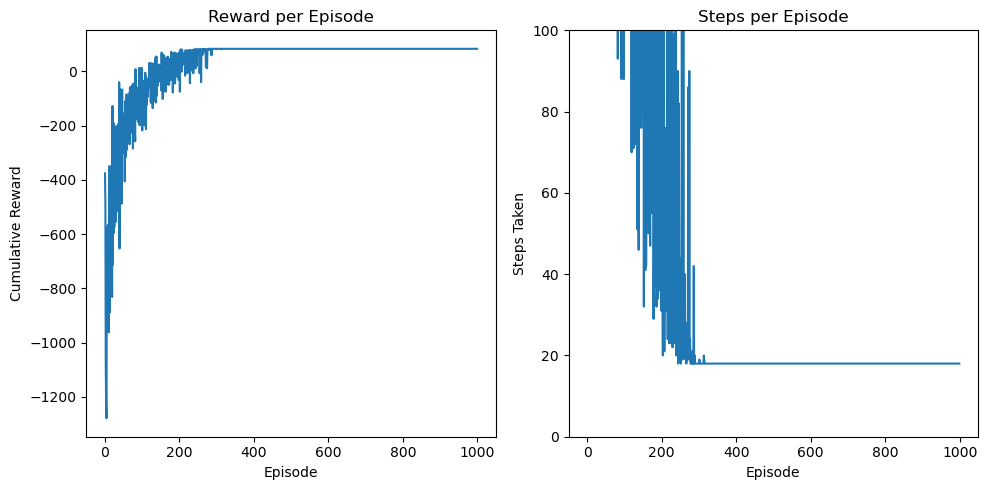

In [288]:
# After training your agent
plot_training_metrics(episode_rewards, episode_steps)


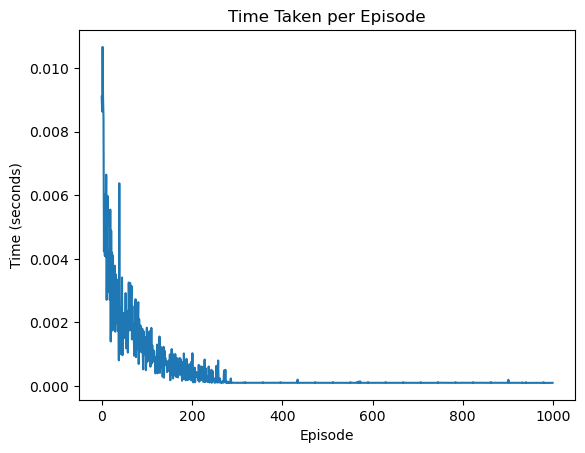

In [289]:
# Plot the time taken per episode
plt.plot(episode_times)
plt.title('Time Taken per Episode')
plt.xlabel('Episode')
plt.ylabel('Time (seconds)')
plt.show()

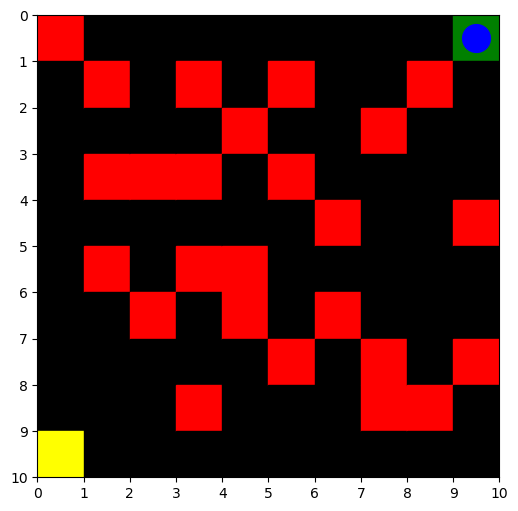

Episode 1 finished after 20 steps with total reward: 81
Test completed over 1 episodes.
Total steps: 20, Total reward: 81


In [290]:
test_agent(agent, env) 

## HyperParameter Turning Using GridSearch

The `hyperparameter_tuning` function optimizes the hyperparameters for the Q-learning agent:
- It iterates through all combinations of the provided hyperparameter values (learning rates, discount factors, etc.).
- For each combination, it trains the agent, then calculates and tracks the average reward and steps.
- The function identifies and returns the hyperparameter combination that results in the best performance, based on average reward.
- The best hyperparameters and their corresponding performance metrics (average reward and steps) are printed for review.


In [293]:
def hyperparameter_tuning(env, learning_rates, discount_factors, exploration_start, exploration_end, num_episodes):
    best_hyperparameters = None
    best_average_reward = float('-inf')  # Initialize to a very low value
    best_average_steps = float('inf')   # Initialize to a very high value

    # Generate all combinations of hyperparameters
    param_combinations = list(product(learning_rates, discount_factors, exploration_start, exploration_end, [num_episodes]))

    for params in param_combinations:
        alpha, gamma, epsilon_start, epsilon_end, episodes = params
        
        # Initialize the agent with the current hyperparameters
        agent = QLearningAgent(env, learning_rate=alpha, discount_factor=gamma, 
                               exploration_start=epsilon_start, exploration_end=epsilon_end, 
                               num_episodes=episodes)
        
        # Train the agent and get the rewards and steps per episode
        episode_rewards, episode_steps, _, _ = train_agent(agent, env, num_episodes=episodes)

        # Calculate the average reward and average steps
        average_reward = sum(episode_rewards) / len(episode_rewards)
        average_steps = sum(episode_steps) / len(episode_steps)

        # Update best hyperparameters if current ones are better
        if average_reward > best_average_reward:
            best_average_reward = average_reward
            best_average_steps = average_steps
            best_hyperparameters = params

    # Return the best hyperparameters and their performance
    print(f"Best Hyperparameters: {best_hyperparameters}")
    print(f"Best Average Reward: {best_average_reward}")
    print(f"Best Average Steps: {best_average_steps}")
    return best_hyperparameters, best_average_reward, best_average_steps


In [294]:
learning_rates = [0.01, 0.1, 0.5]
discount_factors = [0.9, 0.95, 0.99]
exploration_start = [1.0, 0.5]
exploration_end = [0.01, 0.1]
num_episodes = 1000

best_params, best_avg_reward, best_avg_steps = hyperparameter_tuning(env, learning_rates, discount_factors, exploration_start, exploration_end, num_episodes)


Best Hyperparameters: (0.5, 0.95, 0.5, 0.01, 1000)
Best Average Reward: 74.499
Best Average Steps: 26.501


## Training With Best HyperParameter

In [337]:
agent = QLearningAgent(env, learning_rate=0.5, discount_factor=0.95, 
                               exploration_start=0.05, exploration_end= 0.01, 
                               num_episodes= 1000)

episode_rewards_tuned, episode_steps_tuned, paths, tuned_episode_times = train_agent(agent, env, num_episodes=1000)

The average reward is: 78.051
The average steps is: 22.949


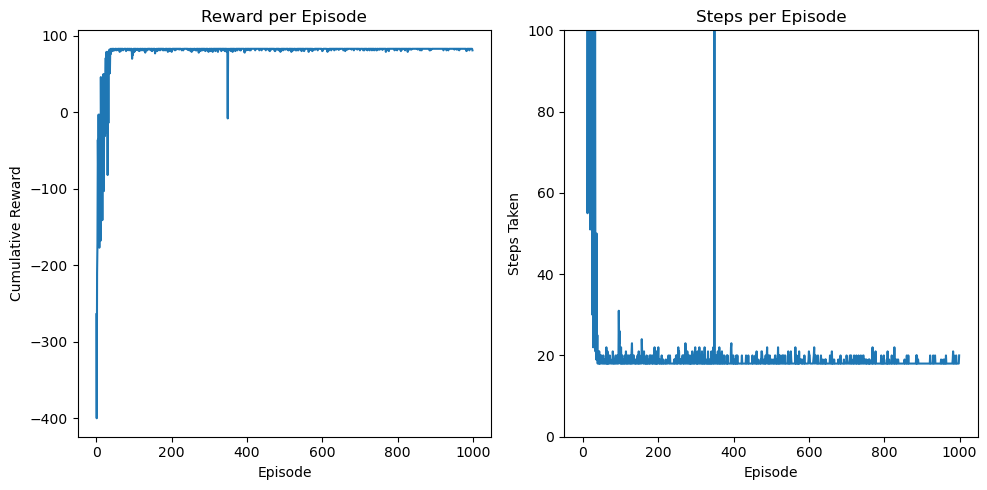

In [339]:
# After training your agent
plot_training_metrics(episode_rewards_tuned, episode_steps_tuned)


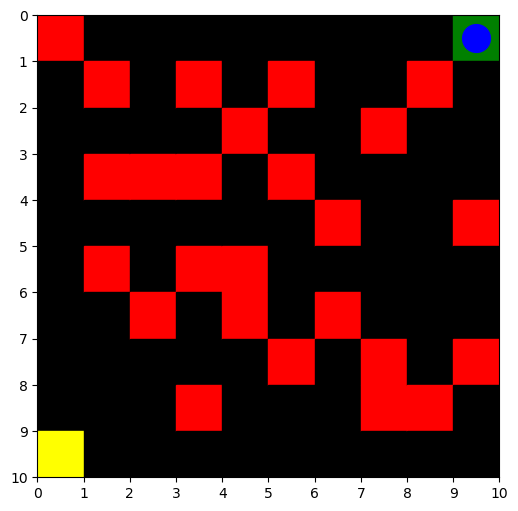

Episode 1 finished after 18 steps with total reward: 83
Test completed over 1 episodes.
Total steps: 18, Total reward: 83


In [341]:
test_agent(agent, env, num_episodes=1)

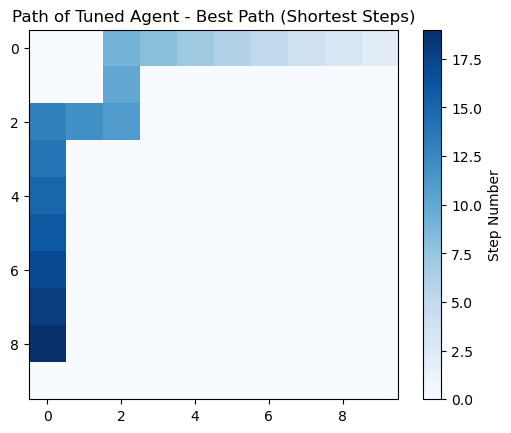

In [343]:
plot_grid_path((10,10), paths, "Path of Tuned Agent")

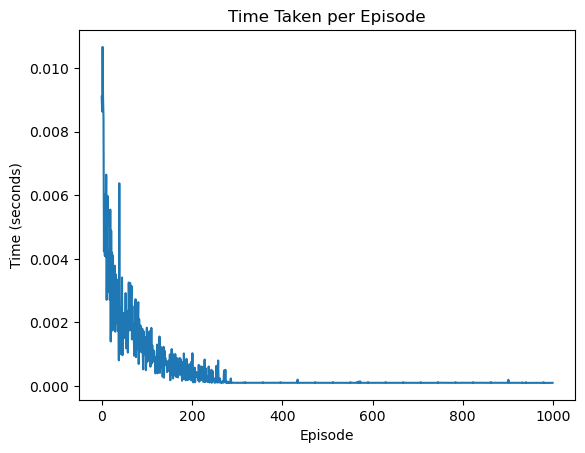

In [345]:
# Plot the time taken per episode
plt.plot(episode_times)
plt.title('Time Taken per Episode')
plt.xlabel('Episode')
plt.ylabel('Time (seconds)')
plt.show()

## Comparing with Reward of Tuned and Non-Tuned Agent

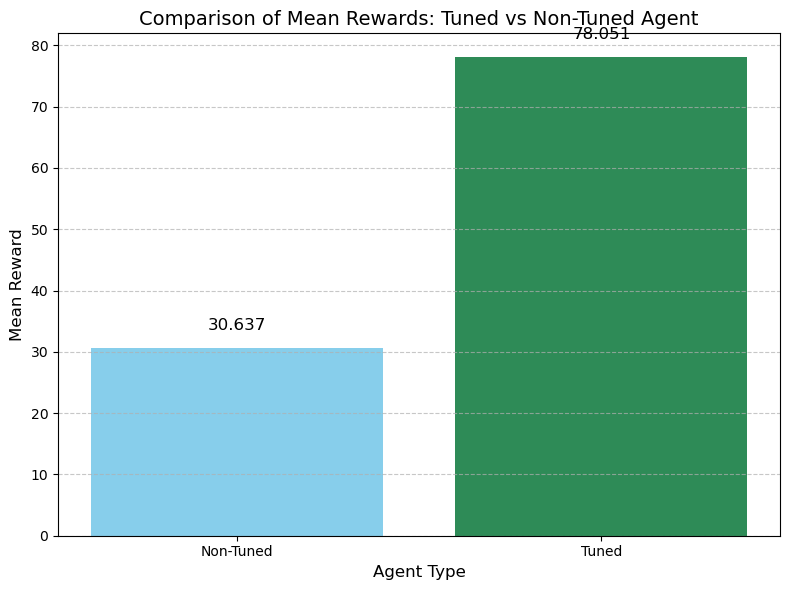

In [348]:
mean_reward = sum(episode_rewards) / len(episode_rewards)
mean_reward_tuned = sum(episode_rewards_tuned) / len(episode_rewards_tuned)

# Example data: Mean rewards for tuned and non-tuned agents
categories = ['Non-Tuned', 'Tuned']
mean_rewards = [mean_reward, mean_reward_tuned]  
# Create the bar chart
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(categories, mean_rewards, color=['skyblue', 'seagreen'])

# Add value annotations to the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 3, f'{yval}', ha='center', fontsize=12)

# Set chart title and labels
ax.set_title('Comparison of Mean Rewards: Tuned vs Non-Tuned Agent', fontsize=14)
ax.set_ylabel('Mean Reward', fontsize=12)
ax.set_xlabel('Agent Type', fontsize=12)

# Display grid for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Show the chart
plt.tight_layout()
plt.show()


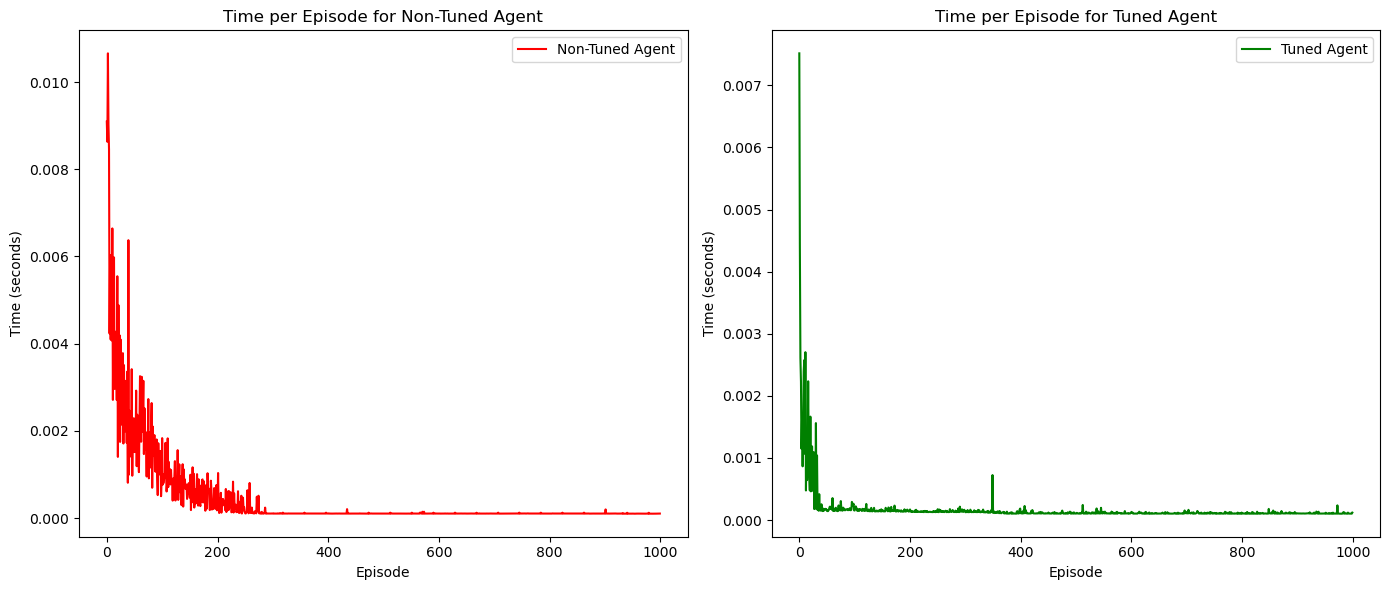

In [350]:
# Create a figure with two subplots (side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot for non-tuned agent (first subplot)
ax1.plot(episode_times, color='r', label="Non-Tuned Agent")
ax1.set_title('Time per Episode for Non-Tuned Agent')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Time (seconds)')
ax1.legend()

# Plot for tuned agent (second subplot)
ax2.plot(tuned_episode_times, color='g', label="Tuned Agent")
ax2.set_title('Time per Episode for Tuned Agent')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Time (seconds)')
ax2.legend()

# Adjust layout for better spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

### Statistical validation

In [353]:
# Perform t-test
t_stat, p_val = stats.ttest_ind(episode_rewards_tuned, episode_rewards)
print(f"T-statistic: {t_stat}, \nP-value: {p_val}")

# Confidence Interval for tuned agent's rewards
confidence_interval = stats.t.interval(0.95, len(episode_rewards_tuned)-1, loc=np.mean(episode_rewards_tuned), scale=stats.sem(episode_rewards_tuned))
print(f"95% Confidence Interval for Tuned Agent's Rewards: {confidence_interval}")


T-statistic: 9.954528149167418, 
P-value: 8.109513411029379e-23
95% Confidence Interval for Tuned Agent's Rewards: (76.16198252750252, 79.94001747249749)


## Save Agent

In [356]:
with open("Grid_world_agent", 'wb') as f:
        pickle.dump(agent, f) 


## Load and Test

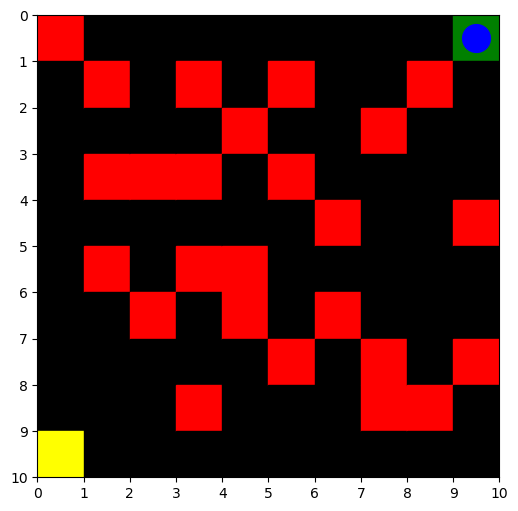

Episode 1 finished after 18 steps with total reward: 83
Test completed over 1 episodes.
Total steps: 18, Total reward: 83


In [361]:
def load_agent(filename):
    with open(filename, 'rb') as f:
        agent = pickle.load(f)  # Deserialize the agent from the file
    print(f"Agent loaded from {filename}")
    return agent

agent_loaded = load_agent('Grid_world_agent')

test_agent(agent_loaded, env, num_episodes=1)